In [ ]:
# This game is based on Q-Leaning ==== Reinforcement leanirng===

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

print("RL setup is ready in Google Colab")

RL setup is ready in Google Colab


In [ ]:
# ==============================
# Step 1: Define the GridWorld
# ==============================

grid_size = 4

start_state = (0, 0)
goal_state = (0, 3)
trap_state = (1, 1)

actions = ["up", "down", "left", "right"]

print("GridWorld created!")
print("Grid size:", grid_size, "x", grid_size)
print("Start:", start_state)
print("Goal:", goal_state)
print("Trap:", trap_state)
print("Actions:", actions)

GridWorld created!
Grid size: 4 x 4
Start: (0, 0)
Goal: (0, 3)
Trap: (1, 1)
Actions: ['up', 'down', 'left', 'right']


In [ ]:
# ==============================
# Step 2: Movement Logic
# ==============================

def move_agent(state, action):
    row, col = state

    if action == "up":
        row -= 1
    elif action == "down":
        row += 1
    elif action == "left":
        col -= 1
    elif action == "right":
        col += 1

    # Prevent the agent from moving outside the grid
    row = max(0, min(row, grid_size - 1))
    col = max(0, min(col, grid_size - 1))

    return (row, col)


# Test movement
current_state = start_state

print("Starting position:", current_state)

for action in actions:
    new_state = move_agent(current_state, action)
    print(f"Action: {action:5s} -> New position: {new_state}")

Starting position: (0, 0)
Action: up    -> New position: (0, 0)
Action: down  -> New position: (1, 0)
Action: left  -> New position: (0, 0)
Action: right -> New position: (0, 1)


In [ ]:
# ==============================
# Step 3: Reward Logic
# ==============================

def get_reward(state):
    if state == goal_state:
        return 10
    elif state == trap_state:
        return -10
    else:
        return -1


def is_game_over(state):
    return state == goal_state or state == trap_state


# Test reward logic
test_states = [
    start_state,
    goal_state,
    trap_state,
    (2, 2)
]

for state in test_states:
    reward = get_reward(state)
    game_over = is_game_over(state)
    print(f"State: {state} -> Reward: {reward}, Game Over: {game_over}")

State: (0, 0) -> Reward: -1, Game Over: False
State: (0, 3) -> Reward: 10, Game Over: True
State: (1, 1) -> Reward: -10, Game Over: True
State: (2, 2) -> Reward: -1, Game Over: False


In [ ]:
# ==============================
# Step 4: Create the Q-table
# ==============================

num_actions = len(actions)

q_table = np.zeros((grid_size, grid_size, num_actions))

print("Q-table created!")
print("Q-table shape:", q_table.shape)
print("\nInitial Q-values at start state:")
print(q_table[start_state[0], start_state[1]])

Q-table created!
Q-table shape: (4, 4, 4)

Initial Q-values at start state:
[0. 0. 0. 0.]


In [ ]:
# ==============================
# Step 5: Action Selection Logic
# ==============================

epsilon = 0.9  # high value means the agent explores a lot at the beginning

def choose_action(state):
    row, col = state

    # Explore: choose a random action
    if random.uniform(0, 1) < epsilon:
        action_index = random.randint(0, num_actions - 1)

    # Exploit: choose the best known action from the Q-table
    else:
        action_index = np.argmax(q_table[row, col])

    return action_index


# Test action selection
current_state = start_state

for i in range(10):
    action_index = choose_action(current_state)
    action_name = actions[action_index]
    print(f"Trial {i+1}: Chosen action index = {action_index}, Action = {action_name}")

Trial 1: Chosen action index = 0, Action = up
Trial 2: Chosen action index = 3, Action = right
Trial 3: Chosen action index = 0, Action = up
Trial 4: Chosen action index = 0, Action = up
Trial 5: Chosen action index = 0, Action = up
Trial 6: Chosen action index = 0, Action = up
Trial 7: Chosen action index = 2, Action = left
Trial 8: Chosen action index = 3, Action = right
Trial 9: Chosen action index = 0, Action = up
Trial 10: Chosen action index = 0, Action = up


In [ ]:
# ==============================
# Step 6: Train the Agent
# ==============================

# Training parameters
alpha = 0.1          # learning rate
gamma = 0.9          # discount factor
epsilon = 0.9        # starting exploration rate
epsilon_decay = 0.995
epsilon_min = 0.05

episodes = 1000
max_steps = 50

reward_history = []

for episode in range(episodes):
    state = start_state
    total_reward = 0

    for step in range(max_steps):
        row, col = state

        # Choose action using epsilon-greedy strategy
        if random.uniform(0, 1) < epsilon:
            action_index = random.randint(0, num_actions - 1)
        else:
            action_index = np.argmax(q_table[row, col])

        action = actions[action_index]

        # Move agent
        next_state = move_agent(state, action)
        next_row, next_col = next_state

        # Get reward
        reward = get_reward(next_state)
        total_reward += reward

        # Current Q-value
        old_q_value = q_table[row, col, action_index]

        # Best future Q-value
        best_future_q = np.max(q_table[next_row, next_col])

        # Q-learning update formula
        new_q_value = old_q_value + alpha * (
            reward + gamma * best_future_q - old_q_value
        )

        # Update Q-table
        q_table[row, col, action_index] = new_q_value

        # Move to next state
        state = next_state

        # Stop if goal or trap is reached
        if is_game_over(state):
            break

    # Reduce exploration gradually
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    reward_history.append(total_reward)

print("Training completed!")
print("Final epsilon:", epsilon)
print("Q-values at start state:")
print(q_table[start_state[0], start_state[1]])

Training completed!
Final epsilon: 0.05
Q-values at start state:
[4.53642899 3.00822452 4.49751498 6.2       ]


In [ ]:
# ==============================
# Step 7: Test the Trained Agent
# ==============================

def test_agent():
    state = start_state
    path = [state]
    total_reward = 0

    print("Testing trained agent...\n")
    print("Start:", state)

    for step in range(max_steps):
        row, col = state

        # Choose the best action from the learned Q-table
        action_index = np.argmax(q_table[row, col])
        action = actions[action_index]

        # Move agent
        next_state = move_agent(state, action)

        # Get reward
        reward = get_reward(next_state)
        total_reward += reward

        print(f"Step {step+1}: Action = {action:5s}, New State = {next_state}, Reward = {reward}")

        path.append(next_state)
        state = next_state

        if is_game_over(state):
            break

    print("\nFinal path:")
    print(path)
    print("Total reward:", total_reward)

    if state == goal_state:
        print("Success! The agent reached the goal.")
    elif state == trap_state:
        print("Oh no! The agent fell into the trap.")
    else:
        print("The agent did not finish within the maximum steps.")

    return path


learned_path = test_agent()

Testing trained agent...

Start: (0, 0)
Step 1: Action = right, New State = (0, 1), Reward = -1
Step 2: Action = right, New State = (0, 2), Reward = -1
Step 3: Action = right, New State = (0, 3), Reward = 10

Final path:
[(0, 0), (0, 1), (0, 2), (0, 3)]
Total reward: 8
Success! The agent reached the goal.


In [ ]:
# ==============================
# Step 8: Visualize the Learned Path
# ==============================

def display_grid(path=None):
    grid = [["." for _ in range(grid_size)] for _ in range(grid_size)]

    # Mark important positions
    grid[start_state[0]][start_state[1]] = "A"
    grid[goal_state[0]][goal_state[1]] = "G"
    grid[trap_state[0]][trap_state[1]] = "X"

    # Mark path
    if path is not None:
        for state in path:
            row, col = state

            # Do not overwrite start, goal, or trap
            if state not in [start_state, goal_state, trap_state]:
                grid[row][col] = "*"

    # Print grid
    for row in grid:
        print("  ".join(row))


print("Learned path on the grid:\n")
display_grid(learned_path)

Learned path on the grid:

A  *  *  G
.  X  .  .
.  .  .  .
.  .  .  .


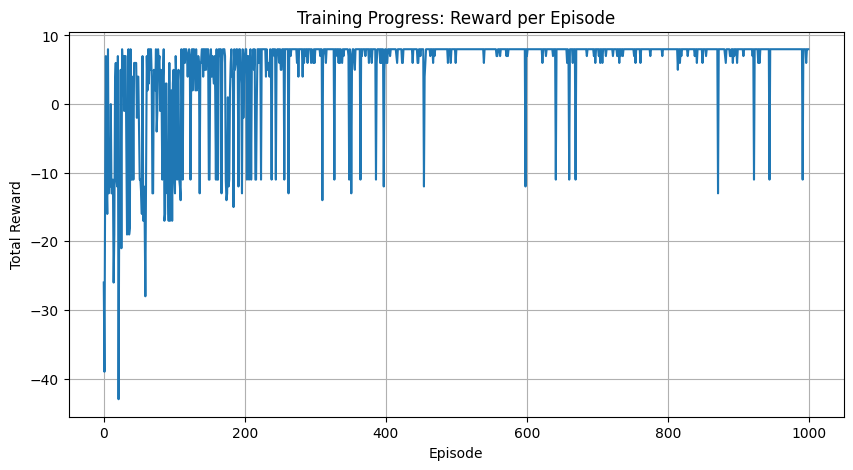

In [ ]:
# ==============================
# Step 9: Plot Training Progress
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Progress: Reward per Episode")
plt.grid(True)
plt.show()

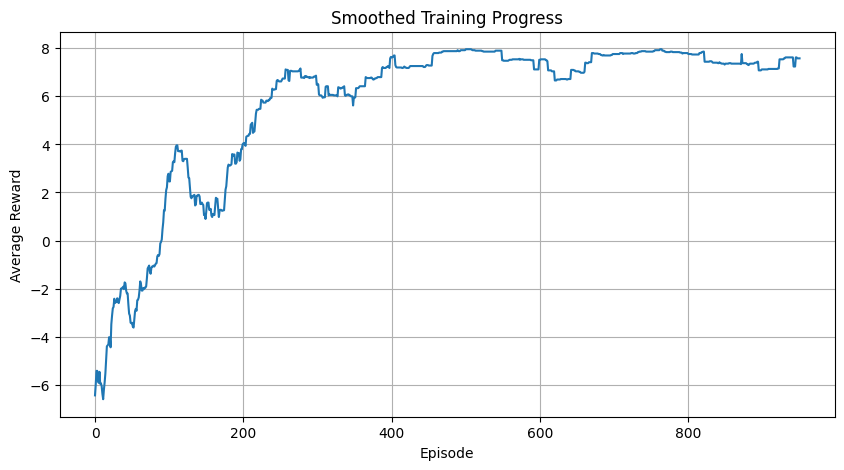

In [ ]:
# ==============================
# Step 10: Smoothed Reward Curve
# ==============================

window_size = 50

smoothed_rewards = np.convolve(
    reward_history,
    np.ones(window_size) / window_size,
    mode="valid"
)

plt.figure(figsize=(10, 5))
plt.plot(smoothed_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Smoothed Training Progress")
plt.grid(True)
plt.show()

In [ ]:
# ==============================
# Step 11: Display Learned Policy
# ==============================

action_symbols = {
    "up": "↑",
    "down": "↓",
    "left": "←",
    "right": "→"
}

def display_policy():
    policy_grid = []

    for row in range(grid_size):
        policy_row = []

        for col in range(grid_size):
            state = (row, col)

            if state == goal_state:
                policy_row.append("G")
            elif state == trap_state:
                policy_row.append("X")
            else:
                best_action_index = np.argmax(q_table[row, col])
                best_action = actions[best_action_index]
                policy_row.append(action_symbols[best_action])

        policy_grid.append(policy_row)

    for row in policy_grid:
        print("  ".join(row))


print("Learned policy:")
display_policy()

Learned policy:
→  →  →  G
↑  X  ↑  ↑
↑  ←  ↑  ↑
↓  →  ←  ↓


In [ ]:
# ==============================
# Step 12: Playable Text Game
# ==============================

def display_playable_grid(agent_state):
    grid = [["." for _ in range(grid_size)] for _ in range(grid_size)]

    grid[goal_state[0]][goal_state[1]] = "G"
    grid[trap_state[0]][trap_state[1]] = "X"
    grid[agent_state[0]][agent_state[1]] = "A"

    for row in grid:
        print("  ".join(row))


def play_game():
    state = start_state
    total_reward = 0

    print("Welcome to GridWorld!")
    print("Controls:")
    print("w = up, s = down, a = left, d = right, q = quit")
    print("Reach G and avoid X.\n")

    while True:
        display_playable_grid(state)

        move = input("\nEnter your move: ").lower()

        if move == "q":
            print("Game quit.")
            break

        if move == "w":
            action = "up"
        elif move == "s":
            action = "down"
        elif move == "a":
            action = "left"
        elif move == "d":
            action = "right"
        else:
            print("Invalid move. Use w, a, s, d, or q.")
            continue

        next_state = move_agent(state, action)
        reward = get_reward(next_state)
        total_reward += reward
        state = next_state

        print(f"\nAction: {action}")
        print(f"Reward: {reward}")
        print(f"Total reward: {total_reward}\n")

        if state == goal_state:
            display_playable_grid(state)
            print("\nCongratulations! You reached the goal.")
            print("Final reward:", total_reward)
            break

        if state == trap_state:
            display_playable_grid(state)
            print("\nOh no! You fell into the trap.")
            print("Final reward:", total_reward)
            break


play_game()

Welcome to GridWorld!
Controls:
w = up, s = down, a = left, d = right, q = quit
Reach G and avoid X.

A  .  .  G
.  X  .  .
.  .  .  .
.  .  .  .

Enter your move: d

Action: right
Reward: -1
Total reward: -1

.  A  .  G
.  X  .  .
.  .  .  .
.  .  .  .

Enter your move: d

Action: right
Reward: -1
Total reward: -2

.  .  A  G
.  X  .  .
.  .  .  .
.  .  .  .

Enter your move: d

Action: right
Reward: 10
Total reward: 8

.  .  .  A
.  X  .  .
.  .  .  .
.  .  .  .

Congratulations! You reached the goal.
Final reward: 8


In [ ]:
# ==============================
# Step 13: RL Agent Demo Mode
# ==============================

import time
from IPython.display import clear_output

def demo_agent(delay=1.0):
    state = start_state
    total_reward = 0
    path = [state]

    print("RL Agent Demo Mode")
    time.sleep(delay)

    for step in range(max_steps):
        clear_output(wait=True)

        print("RL Agent Demo Mode")
        print(f"Step: {step}")
        print(f"Current state: {state}")
        print(f"Total reward: {total_reward}\n")

        display_playable_grid(state)
        time.sleep(delay)

        row, col = state

        # Agent chooses the best action from learned Q-table
        action_index = np.argmax(q_table[row, col])
        action = actions[action_index]

        next_state = move_agent(state, action)
        reward = get_reward(next_state)

        total_reward += reward
        state = next_state
        path.append(state)

        if is_game_over(state):
            clear_output(wait=True)

            print("RL Agent Demo Mode")
            print(f"Final step: {step + 1}")
            print(f"Final state: {state}")
            print(f"Total reward: {total_reward}")
            print(f"Path: {path}\n")

            display_playable_grid(state)

            if state == goal_state:
                print("\nSuccess! The RL agent reached the goal.")
            else:
                print("\nThe RL agent fell into the trap.")

            break

demo_agent(delay=1.0)

RL Agent Demo Mode
Final step: 3
Final state: (0, 3)
Total reward: 8
Path: [(0, 0), (0, 1), (0, 2), (0, 3)]

.  .  .  A
.  X  .  .
.  .  .  .
.  .  .  .

Success! The RL agent reached the goal.


In [ ]:
# ==============================
# Step 14: Harder 10-Step GridWorld Setup
# ==============================

grid_size = 6

start_state = (0, 0)
goal_state = (5, 5)

trap_states = [
    (1, 1),
    (1, 3),
    (2, 3),
    (3, 1),
    (4, 2)
]

actions = ["up", "down", "left", "right"]
num_actions = len(actions)

# Recreate Q-table for the new 6x6 game
q_table = np.zeros((grid_size, grid_size, num_actions))

print("10-step GridWorld created!")
print("Grid size:", grid_size, "x", grid_size)
print("Start:", start_state)
print("Goal:", goal_state)
print("Traps:", trap_states)
print("Shortest possible path length: 10 steps")

10-step GridWorld created!
Grid size: 6 x 6
Start: (0, 0)
Goal: (5, 5)
Traps: [(1, 1), (1, 3), (2, 3), (3, 1), (4, 2)]
Shortest possible path length: 10 steps


In [ ]:
# ==============================
# Step 15: Updated Reward Logic
# ==============================

def get_reward(state):
    if state == goal_state:
        return 30
    elif state in trap_states:
        return -30
    else:
        return -1


def is_game_over(state):
    return state == goal_state or state in trap_states

In [ ]:
# ==============================
# Step 16: Display 10-Step GridWorld
# ==============================

def display_grid(path=None):
    grid = [["." for _ in range(grid_size)] for _ in range(grid_size)]

    grid[start_state[0]][start_state[1]] = "A"
    grid[goal_state[0]][goal_state[1]] = "G"

    for trap in trap_states:
        grid[trap[0]][trap[1]] = "X"

    if path is not None:
        for state in path:
            row, col = state
            if state != start_state and state != goal_state and state not in trap_states:
                grid[row][col] = "*"

    for row in grid:
        print("  ".join(row))


print("10-step GridWorld:")
display_grid()

10-step GridWorld:
A  .  .  .  .  .
.  X  .  X  .  .
.  .  .  X  .  .
.  X  .  .  .  .
.  .  X  .  .  .
.  .  .  .  .  G


In [ ]:
# ==============================
# Step 17: Train Agent on 10-Step GridWorld
# ==============================

alpha = 0.1
gamma = 0.9
epsilon = 0.9
epsilon_decay = 0.995
epsilon_min = 0.05

episodes = 3000
max_steps = 100

reward_history = []

for episode in range(episodes):
    state = start_state
    total_reward = 0

    for step in range(max_steps):
        row, col = state

        if random.uniform(0, 1) < epsilon:
            action_index = random.randint(0, num_actions - 1)
        else:
            action_index = np.argmax(q_table[row, col])

        action = actions[action_index]

        next_state = move_agent(state, action)
        next_row, next_col = next_state

        reward = get_reward(next_state)
        total_reward += reward

        old_q_value = q_table[row, col, action_index]
        best_future_q = np.max(q_table[next_row, next_col])

        new_q_value = old_q_value + alpha * (
            reward + gamma * best_future_q - old_q_value
        )

        q_table[row, col, action_index] = new_q_value

        state = next_state

        if is_game_over(state):
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    reward_history.append(total_reward)

print("Training completed!")
print("Final epsilon:", epsilon)
print("Q-values at start state:")
print(q_table[start_state[0], start_state[1]])

Training completed!
Final epsilon: 0.05
Q-values at start state:
[3.77100832 5.49681956 3.74533157 2.16643529]


In [ ]:
# ==============================
# Step 18: Test 10-Step Agent
# ==============================

def test_agent_10_step():
    state = start_state
    path = [state]
    total_reward = 0

    print("Testing trained agent on 10-step GridWorld...\n")
    print("Start:", state)

    for step in range(max_steps):
        row, col = state

        # Choose best learned action
        action_index = np.argmax(q_table[row, col])
        action = actions[action_index]

        next_state = move_agent(state, action)
        reward = get_reward(next_state)

        total_reward += reward

        print(
            f"Step {step + 1}: "
            f"Action = {action:5s}, "
            f"New State = {next_state}, "
            f"Reward = {reward}"
        )

        path.append(next_state)
        state = next_state

        if is_game_over(state):
            break

    print("\nFinal path:")
    print(path)
    print("Number of steps:", len(path) - 1)
    print("Total reward:", total_reward)

    if state == goal_state:
        print("Success! The agent reached the goal.")
    elif state in trap_states:
        print("Oh no! The agent fell into a trap.")
    else:
        print("The agent did not finish within the maximum steps.")

    return path


learned_path_10 = test_agent_10_step()

Testing trained agent on 10-step GridWorld...

Start: (0, 0)
Step 1: Action = down , New State = (1, 0), Reward = -1
Step 2: Action = down , New State = (2, 0), Reward = -1
Step 3: Action = right, New State = (2, 1), Reward = -1
Step 4: Action = right, New State = (2, 2), Reward = -1
Step 5: Action = down , New State = (3, 2), Reward = -1
Step 6: Action = right, New State = (3, 3), Reward = -1
Step 7: Action = right, New State = (3, 4), Reward = -1
Step 8: Action = down , New State = (4, 4), Reward = -1
Step 9: Action = right, New State = (4, 5), Reward = -1
Step 10: Action = down , New State = (5, 5), Reward = 30

Final path:
[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3), (3, 4), (4, 4), (4, 5), (5, 5)]
Number of steps: 10
Total reward: 21
Success! The agent reached the goal.


In [ ]:
# ==============================
# Step 20: Playable 10-Step Game
# ==============================

def display_playable_grid(agent_state):
    grid = [["." for _ in range(grid_size)] for _ in range(grid_size)]

    grid[goal_state[0]][goal_state[1]] = "G"

    for trap in trap_states:
        grid[trap[0]][trap[1]] = "X"

    grid[agent_state[0]][agent_state[1]] = "A"

    for row in grid:
        print("  ".join(row))


def play_10_step_game():
    state = start_state
    total_reward = 0
    steps = 0

    print("Welcome to the 10-step GridWorld!")
    print("Controls: w = up, s = down, a = left, d = right, q = quit")
    print("Goal: Reach G and avoid X.\n")

    while True:
        display_playable_grid(state)

        move = input("\nEnter your move: ").lower()

        if move == "q":
            print("Game quit.")
            break

        if move == "w":
            action = "up"
        elif move == "s":
            action = "down"
        elif move == "a":
            action = "left"
        elif move == "d":
            action = "right"
        else:
            print("Invalid move. Use w, a, s, d, or q.")
            continue

        next_state = move_agent(state, action)
        reward = get_reward(next_state)

        total_reward += reward
        steps += 1
        state = next_state

        print(f"\nAction: {action}")
        print(f"Steps taken: {steps}")
        print(f"Reward: {reward}")
        print(f"Total reward: {total_reward}\n")

        if state == goal_state:
            display_playable_grid(state)
            print("\nCongratulations! You reached the goal.")
            print("Final steps:", steps)
            print("Final reward:", total_reward)
            break

        if state in trap_states:
            display_playable_grid(state)
            print("\nOh no! You fell into a trap.")
            print("Final steps:", steps)
            print("Final reward:", total_reward)
            break


play_10_step_game()

Welcome to the 10-step GridWorld!
Controls: w = up, s = down, a = left, d = right, q = quit
Goal: Reach G and avoid X.

A  .  .  .  .  .
.  X  .  X  .  .
.  .  .  X  .  .
.  X  .  .  .  .
.  .  X  .  .  .
.  .  .  .  .  G

Enter your move: d

Action: right
Steps taken: 1
Reward: -1
Total reward: -1

.  A  .  .  .  .
.  X  .  X  .  .
.  .  .  X  .  .
.  X  .  .  .  .
.  .  X  .  .  .
.  .  .  .  .  G

Enter your move: d

Action: right
Steps taken: 2
Reward: -1
Total reward: -2

.  .  A  .  .  .
.  X  .  X  .  .
.  .  .  X  .  .
.  X  .  .  .  .
.  .  X  .  .  .
.  .  .  .  .  G

Enter your move: d

Action: right
Steps taken: 3
Reward: -1
Total reward: -3

.  .  .  A  .  .
.  X  .  X  .  .
.  .  .  X  .  .
.  X  .  .  .  .
.  .  X  .  .  .
.  .  .  .  .  G

Enter your move: d

Action: right
Steps taken: 4
Reward: -1
Total reward: -4

.  .  .  .  A  .
.  X  .  X  .  .
.  .  .  X  .  .
.  X  .  .  .  .
.  .  X  .  .  .
.  .  .  .  .  G

Enter your move: d

Action: right
Steps taken: 5
Rewa